In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mp # подключение библиотек

In [ ]:
# url = 'https://github.com/SZtrue/aie-SZ/blob/main/homeworks/HW02/S02-hw-dataset.csv'
url = 'https://raw.githubusercontent.com/SZtrue/aie-SZ/main/homeworks/HW02/S02-hw-dataset.csv'
# file='S02-hw-dataset_csv.csv'
data = pd.read_csv(url, sep=',')
data # загрузка учебного датасета

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296
5,6,120.0,FR,-1,785
6,7,46.0,RU,0,0
7,8,28.0,CN,2,456
8,9,39.0,US,4,980
9,10,24.0,RU,7,511


In [ ]:
data.head(n=1)  # вывод первой строки датасета

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749


In [ ]:
data.info() # информация о таблице


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


In [ ]:
data.shape  # размнер таблицы

(41, 5)

In [ ]:
data.describe
data.describe()
data.describe(include='all') # статистика по столбцам

,user_id,age,country,purchases,revenue
count,41.000000,39.000000,41,41.000000,41.000000
unique,NaN,NaN,5,NaN,NaN
top,NaN,NaN,RU,NaN,NaN
freq,NaN,NaN,13,NaN,NaN
mean,20.243902,36.512821,NaN,4.829268,820.048780
std,11.659289,18.304259,NaN,2.710189,613.127269
min,1.000000,5.000000,NaN,-1.000000,0.000000
25%,10.000000,24.000000,NaN,3.000000,432.000000
50%,20.000000,33.000000,NaN,5.000000,693.000000
75%,30.000000,45.500000,NaN,7.000000,1115.000000


In [ ]:
data.duplicated() # выяснили, что последняя строка является копией одной из предыдущих строк

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [ ]:
data.isna().mean() # доля пропусков по столбцам


,0
user_id,0.00000
age,0.04878
country,0.00000
purchases,0.00000
revenue,0.00000


In [ ]:
highage=data['age']>100 # найти элементы в столбце "age" со значением больше 100
sum(highage)

1

In [ ]:
lowage=data['age']<0 # найти элементы в столбце "age" со значением меньше 0
sum(lowage)

0

In [ ]:
lowpurchases=data['purchases']<0 # найти элементы в столбце "lowpurchases" со значением меньше 0
sum(lowpurchases)

1

In [ ]:
lowrevenue=data['revenue']<0 # найти элементы в столбце "revenue" со значением меньше 0
sum(lowrevenue)

0

In [ ]:
outrevenue=(data['revenue']==0) & (data['purchases']>0) # покупки есть, выручки нет
sum(outrevenue)

1

In [ ]:
# найдены возраст больше 100, отрицательное количество покупок, нулевая выручка при наличии покупки, не во всех строках указан возраст

In [ ]:
data.value_counts('country') # посчитали частоту стран в столбце country


,count
country,
RU,13
FR,12
US,8
DE,6
CN,2


In [ ]:
group=data.groupby('purchases') # группировка по частоте количества покупок
group.size()

,0
purchases,
-1,1
0,3
1,1
2,3
3,5
4,4
5,4
6,8
7,8


In [ ]:
# чаще всего встречаются 6 или 7 покупок, реже всего 1 и 11 покупок (0 и -1 покупки в расчёт не брал). Результаты соответствуют нормальному распределению.

FileNotFoundError: [Errno 2] No such file or directory: 'https://github.com/SZtrue/aie-SZ/blob/main/homeworks/HW02/figures/f1.png'

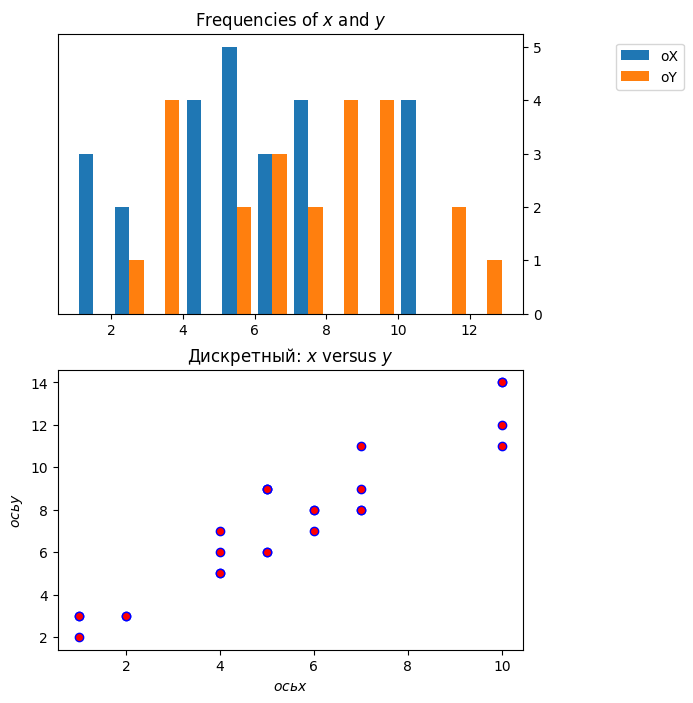

In [ ]:
import matplotlib.pyplot as plt # подключаем библиотеку matplotlib
import numpy as np
np.random.seed(555) # генератор случайных чисел

# задаем данные
x = np.random.randint(low=1, high=11, size=25) # задаём массив по х из 25 чисел
y = x + np.random.randint(1, 5, size=x.size) # задаём массив по y
data = np.column_stack((x, y)) # задаём двумерный массив из элементов х и y

fig, (ax2, ax1) = plt.subplots( #делаем полотно с гистограммой
    nrows=2, ncols=1, # расположенными в два ряда и один столбец
    figsize=(6, 8) # размер полотна
) #

ax1.scatter(x=x, y=y, marker='o', c='r', edgecolor='b') # строим первый график дискретного распределения
ax1.set_title('Дискретный: $x$ versus $y$') # название первого графика
ax1.set_xlabel('$ось x$') # название горизонтальной оси первого графика, используем курсив
ax1.set_ylabel('$ось y$') # название вертикальной оси первого графика, используем курсив


ax2.hist( # строим гистограмму
    data, bins=np.arange(data.min(), data.max()), # задаем данные и диапазоны
    label=('oX', 'oY') # и подписи данных
)

ax2.legend(loc=(1.2, 0.8)) # отображаем легенду и задаем ее расположение
ax2.set_title('Frequencies of $x$ and $y$') # название второго графика
ax2.yaxis.tick_right() # устанавливаем, что вертикальная ось должна быть справа

#url2='https://raw.githubusercontent.com/SZtrue/aie-SZ/refs/heads/main/homeworks/HW02/figures/figure1'
#plt.savefig('https://github.com/SZtrue/aie-SZ/blob/main/homeworks/HW02/figures/f1.png')

plt.show() # отображаем полотна